<a href="https://colab.research.google.com/github/nisha-s10/Deep-Learning-Lab-AFI524/blob/main/Assignment%202/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PART 1 — DATA PREPARATION

### Load Dataset
We’ll use Keras IMDB dataset.

In [1]:
pip install tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

### Hyperparameters

In [3]:
vocab_size = 20000
max_len = 250

### Load Data

In [4]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Split validation:

In [5]:
x_val = x_train[:5000]
y_val = y_train[:5000]

x_train = x_train[5000:]
y_train = y_train[5000:]

### Pad Sequences

In [6]:
x_train = pad_sequences(x_train, maxlen=max_len, padding='post', truncating='post')
x_val = pad_sequences(x_val, maxlen=max_len, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=max_len, padding='post', truncating='post')

### Vocabulary Info

In [7]:
print("Vocabulary Size:", vocab_size)
print("Max Sequence Length:", max_len)

Vocabulary Size: 20000
Max Sequence Length: 250


To decode raw text:

In [8]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(sequence):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in sequence])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Example Raw Text vs Processed Sequence

In [9]:
print("Example Processed Sequence:", x_train[0][:20])
print("Example Raw Review:\n", decode_review(x_train[0]))

Example Processed Sequence: [   1   13  104   14 2856   77    6  542   20    5   49    7   94  531
   26  608   21   11  226   45]
Example Raw Review:
 ? i think this could've been a decent movie and some of its parts are ok but in whole it's a b movie same about the plot parts are ok but it has several holes and oddities that doesn't quite add up acting is mostly ok i've seen worse of this too br br the beginning sets the level with cars driving in the desert making cool but totally unnecessary jumps through some small ? in slow motion cool like the drivers had never seen sand before it gets slightly better from there but not much br br if you're gonna rent this get another one too and use this one as a warm up keep expectations low and it might work for you ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? 

## PART 2 — MODEL 1: Baseline Simple RNN

### Architecture

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

embed_dim = 128
rnn_units = 64

model_baseline = Sequential([
    Embedding(vocab_size, embed_dim),
    SimpleRNN(rnn_units),
    Dense(1, activation='sigmoid')
])

model_baseline.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', AUC(name='auc')]
)

### Train Model

In [11]:
early_stop = EarlyStopping(patience=2, restore_best_weights=True)

history_baseline = model_baseline.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)
model_baseline.summary()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 115ms/step - accuracy: 0.5032 - auc: 0.5000 - loss: 0.6970 - val_accuracy: 0.4968 - val_auc: 0.5138 - val_loss: 0.6953
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.6004 - auc: 0.6748 - loss: 0.6414 - val_accuracy: 0.5018 - val_auc: 0.5026 - val_loss: 0.7359
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.6610 - auc: 0.7683 - loss: 0.5081 - val_accuracy: 0.5002 - val_auc: 0.4979 - val_loss: 0.8415


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,717,253 (29.44 MB)

 Trainable params: 2,572,417 (9.81 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,144,836 (19.63 MB)

### Plot Training Curves

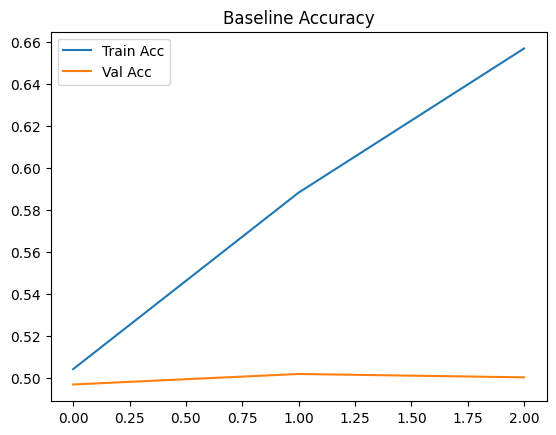

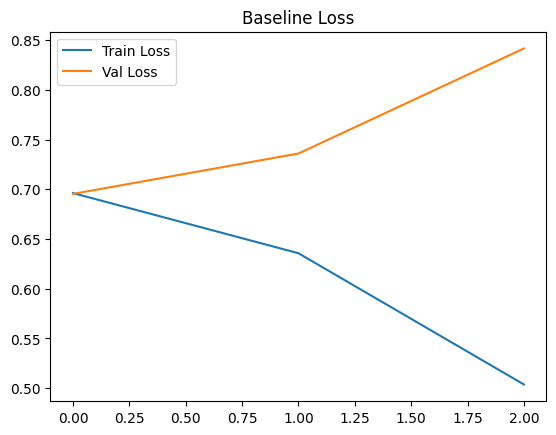

In [12]:
plt.plot(history_baseline.history['accuracy'], label='Train Acc')
plt.plot(history_baseline.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Baseline Accuracy")
plt.show()

plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Baseline Loss")
plt.show()

## PART 3 — Improved Simple RNN

Improvements Used:

*   Bidirectional(SimpleRNN)
*   Dropout
*   SpatialDropout1D

In [13]:
from tensorflow.keras.layers import Dropout, Bidirectional, SpatialDropout1D

model_improved = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embed_dim),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.SimpleRNN(64)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_improved.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

history_improved = model_improved.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 196ms/step - accuracy: 0.5051 - auc: 0.5051 - loss: 0.7092 - val_accuracy: 0.4926 - val_auc: 0.5235 - val_loss: 0.6983
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 62s 196ms/step - accuracy: 0.5142 - auc: 0.5244 - loss: 0.7109 - val_accuracy: 0.5254 - val_auc: 0.5489 - val_loss: 0.6907
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 188ms/step - accuracy: 0.5326 - auc: 0.5500 - loss: 0.6941 - val_accuracy: 0.5378 - val_auc: 0.6098 - val_loss: 0.6873
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 191ms/step - accuracy: 0.6413 - auc: 0.6949 - loss: 0.6387 - val_accuracy: 0.7186 - val_auc: 0.7764 - val_loss: 0.5688
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 186ms/step - accuracy: 0.7805 - auc: 0.8498 - loss: 0.4833 - val_accuracy: 0.7830 - val_auc: 0.8386 - val_loss: 0.5053
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 185ms/step - accuracy: 0.8478 - auc: 0.9147 - loss: 0.3719 - val_accuracy: 0.6872 - val_auc: 0.7629 - val_loss: 0.5857
Epoch 7/10
313/313 ━━━

## PART 4 — EVALUATION

### Evaluate on Test Set

In [14]:
test_loss, test_acc, test_auc = model_improved.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)
print("Test AUC:", test_auc)

model_improved.summary()

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7579 - auc: 0.8129 - loss: 0.5498
Test Accuracy: 0.7568399906158447
Test AUC: 0.8119298815727234


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,754,501 (29.58 MB)

 Trainable params: 2,584,833 (9.86 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,169,668 (19.72 MB)

### Precision, Recall, F1

In [15]:
y_pred_probs = model_improved.predict(x_test)
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step
              precision    recall  f1-score   support

           0       0.81      0.68      0.74     12500
           1       0.72      0.84      0.78     12500

    accuracy                           0.76     25000
   macro avg       0.76      0.76      0.76     25000
weighted avg       0.76      0.76      0.76     25000



### Confusion Matrix

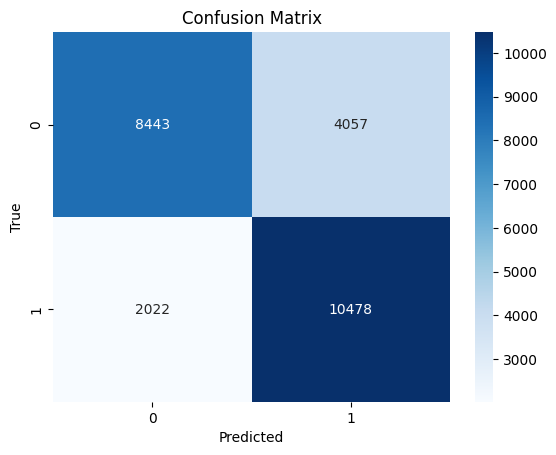

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

### 5 Misclassified Examples

In [17]:
misclassified = np.where(y_pred.flatten() != y_test)[0]

for i in misclassified[:5]:
    print("Review Snippet:", decode_review(x_test[i])[:300])
    print("True Label:", y_test[i])
    print("Predicted Prob:", y_pred_probs[i][0])
    print("-"*50)

Review Snippet: ? i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it this was absolutely idiotic the things that happen with the dead kids are very cool but the alive people are absolute idiots i am a grown man pretty b
True Label: 0
Predicted Prob: 0.899318
--------------------------------------------------
Review Snippet: ? i'm absolutely disgusted this movie isn't being sold all who love this movie should email disney and increase the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn
True Label: 1
Predicted Prob: 0.10685652
--------------------------------------------------
Review Snippet: ? originally supposed to be just a part of a huge epic the year ? depicting the revolution of ? ? is the story of the mutiny of the crew of the ? in ? harbor the film o